In [1]:

!pip install numpy matplotlib ipywidgets



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# Configuración de la población real (Naturaleza)
# Usaremos una distribución exponencial para que sea más evidente cómo 
# las medias se vuelven simétricas y estables (Teorema del Límite Central + LLN)
MEDIA_POBLACIONAL = 10
NUM_SIMULACIONES = 1000

def simular_lln(n):
    # Generamos la semilla para reproducibilidad
    np.random.seed(42)
    
    # 1. Simulamos tomar 'NUM_SIMULACIONES' muestras, cada una de tamaño 'n'
    muestras = np.random.exponential(scale=MEDIA_POBLACIONAL, size=(NUM_SIMULACIONES, n))
    
    # 2. Calculamos la media de cada una de las 1000 muestras
    medias_muestrales = muestras.mean(axis=1)
    
    # 3. Calculamos el Error Estándar Teórico y el Empírico (Varianza colapsando)
    error_estandar_teorico = MEDIA_POBLACIONAL / np.sqrt(n)
    error_estandar_empirico = np.std(medias_muestrales)
    
    # --- GRÁFICA ---
    plt.figure(figsize=(12, 6))
    
    # Histograma de las 1000 medias calculadas
    plt.hist(medias_muestrales, bins=40, density=True, alpha=0.6, color='#1f77b4', edgecolor='white',
             label=f'Distribución de las {NUM_SIMULACIONES} Medias')
    
    # Línea vertical en la verdadera media poblacional
    plt.axvline(MEDIA_POBLACIONAL, color='red', linestyle='--', linewidth=2.5, 
                label=f'Media Poblacional Real (μ = {MEDIA_POBLACIONAL})')
    
    # Configuración visual
    plt.xlim(0, 20)
    plt.ylim(0, 1.5)
    plt.title(f'Ley de los Grandes Números y Consistencia (Tamaño de muestra n = {n})', fontsize=14, fontweight='bold')
    plt.xlabel('Valor de la Media Muestral ($\overline{x}$)', fontsize=12)
    plt.ylabel('Densidad de Probabilidad', fontsize=12)
    
    # Anotaciones de las métricas clave
    texto_metricas = (
        f'Tamaño de muestra ($n$): {n}\n'
        f'Error Estándar Teórico ($\sigma / \sqrt{{n}}$): {error_estandar_teorico:.4f}\n'
        f'Desviación Real de las Medias: {error_estandar_empirico:.4f}'
    )
    plt.gcf().text(0.15, 0.70, texto_metricas, fontsize=11, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Crear el control interactivo en Jupyter
interact(simular_lln, n=widgets.IntSlider(min=2, max=500, step=5, value=5, description='Tamaño n:'));


<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:47: SyntaxWarning: invalid escape sequence '\s'
C:\Users\avazq\AppData\Local\Temp\ipykernel_18592\703909970.py:41: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Valor de la Media Muestral ($\overline{x}$)', fontsize=12)
C:\Users\avazq\AppData\Local\Temp\ipykernel_18592\703909970.py:47: SyntaxWarning: invalid escape sequence '\s'
  f'Error Estándar Teórico ($\sigma / \sqrt{{n}}$): {error_estandar_teorico:.4f}\n'


interactive(children=(IntSlider(value=5, description='Tamaño n:', max=500, min=2, step=5), Output()), _dom_cla…

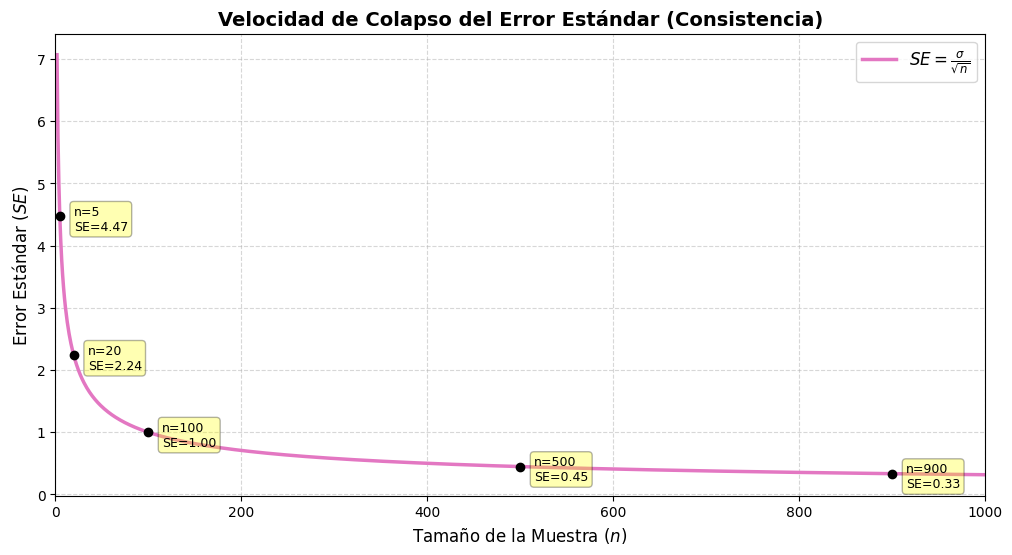

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración
sigma = 10  # Desviación estándar poblacional fija
n_valores = np.arange(2, 1000)  # Tamaños de muestra de 2 a 1000

# Cálculo del Error Estándar Teórico (SE = sigma / sqrt(n))
error_estandar = sigma / np.sqrt(n_valores)

# --- GRÁFICA ---
plt.figure(figsize=(12, 6))
plt.plot(n_valores, error_estandar, color='#e377c2', linewidth=2.5, label=r'$SE = \frac{\sigma}{\sqrt{n}}$')

# Puntos de control para visualizar la velocidad de cambio
puntos_n = [5, 20, 100, 500, 900]
for n_c in puntos_n:
    se_c = sigma / np.sqrt(n_c)
    plt.scatter(n_c, se_c, color='black', zorder=5)
    plt.annotate(f'n={n_c}\nSE={se_c:.2f}', (n_c, se_c), textcoords="offset points", 
                 xytext=(10,-10), ha='left', fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))

plt.title('Velocidad de Colapso del Error Estándar (Consistencia)', fontsize=14, fontweight='bold')
plt.xlabel('Tamaño de la Muestra ($n$)', fontsize=12)
plt.ylabel('Error Estándar ($SE$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 1000)
plt.legend(fontsize=12)
plt.show()


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

NUM_SIMULACIONES = 1000

def simular_varianza_infinita(n):
    np.random.seed(42)
    
    # Simulamos muestras de una distribución de Cauchy (Varianza Infinita)
    # Su "centro" teórico es 0, pero la media muestral no va a converger de forma consistente
    muestras_cauchy = np.random.standard_cauchy(size=(NUM_SIMULACIONES, n))
    
    # Calculamos las medias de cada muestra
    medias_cauchy = muestras_cauchy.mean(axis=1)
    
    # --- GRÁFICA ---
    plt.figure(figsize=(12, 6))
    
    # Recortamos los límites del histograma porque Cauchy genera valores de +/- 10,000 fácilmente
    plt.hist(medias_cauchy, bins=100, range=(-20, 20), density=True, alpha=0.6, 
             color='#d62728', edgecolor='white', label='Medias de Muestras Cauchy')
    
    plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Centro Teórico (0)')
    
    plt.xlim(-20, 20)
    plt.ylim(0, 0.5)
    plt.title(f'Fallo de la LLN: Distribución de Cauchy (Varianza Infinita) con $n$ = {n}', fontsize=14, fontweight='bold')
    plt.xlabel('Valor de la Media Muestral ($\overline{x}$)', fontsize=12)
    plt.ylabel('Densidad de Probabilidad', fontsize=12)
    
    # Calculamos la varianza empírica de las medias observadas en este rango
    var_empirica = np.var(medias_cauchy)
    
    texto = (
        f'Tamaño de muestra ($n$): {n}\n'
        f'Varianza Empírica de las Medias: {var_empirica:.2f}\n'
        f'¡Nota cómo la varianza NO colapsa a cero\n'
        f'ni se encoge el histograma al aumentar $n$!'
    )
    plt.gcf().text(0.15, 0.70, texto, fontsize=11, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Control interactivo
interact(simular_varianza_infinita, n=widgets.IntSlider(min=5, max=1000, step=20, value=5, description='Tamaño n:'));


<>:30: SyntaxWarning: invalid escape sequence '\o'
<>:30: SyntaxWarning: invalid escape sequence '\o'
C:\Users\avazq\AppData\Local\Temp\ipykernel_18592\998659716.py:30: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Valor de la Media Muestral ($\overline{x}$)', fontsize=12)


interactive(children=(IntSlider(value=5, description='Tamaño n:', max=1000, min=5, step=20), Output()), _dom_c…

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
from scipy.stats import skewnorm

def calcular_momentos_centrales(datos):
    n = len(datos)
    media = np.mean(datos)
    
    # Cálculo manual de los momentos centrales muestrales (m_k)
    m1 = np.mean(datos - media)
    m2 = np.mean((datos - media)**2)
    m3 = np.mean((datos - media)**3)
    m4 = np.mean((datos - media)**4)
    
    # Versiones estandarizadas (Asimetría y Curtosis tradicionales)
    asimetria_estandarizada = m3 / (m2 ** 1.5) if m2 > 0 else 0
    curtosis_estandarizada = m4 / (m2 ** 2) if m2 > 0 else 0
    
    return m1, m2, m3, m4, asimetria_estandarizada, curtosis_estandarizada

def graficar_momentos(asimetria, outliers):
    np.random.seed(42)
    n_muestras = 500
    
    # 1. Generamos una base de datos con la asimetría seleccionada
    datos = skewnorm.rvs(a=asimetria, loc=0, scale=2, size=n_muestras)
    
    # 2. Inyectamos outliers (datos extremos) a la derecha para alterar el 4to momento
    if outliers > 0:
        puntos_extremos = np.random.uniform(10, 10 + outliers, size=int(n_muestras * 0.05))
        datos = np.concatenate([datos, puntos_extremos])
    
    # Calcular la media muestral para el gráfico
    media_muestral = np.mean(datos)
    
    # Calcular los momentos muestrales
    m1, m2, m3, m4, g1, g2 = calcular_momentos_centrales(datos)
    
    # --- DISEÑO DE LA GRÁFICA ---
    plt.figure(figsize=(14, 7))
    
    # Histograma de los datos de la muestra
    plt.hist(datos, bins=40, density=True, alpha=0.6, color='#2ca02c', edgecolor='white', label='Datos de la Muestra')
    
    # Línea de la Media Muestral (El pivote/punto de apoyo del subibaja)
    plt.axvline(media_muestral, color='red', linestyle='--', linewidth=2.5, 
                label=f'1er Momento (Pivote): Media ($\overline{{x}}$) = {media_muestral:.2f}')
    
    # Configuración de ejes
    plt.xlim(-8, 22)
    plt.ylim(0, 0.4)
    plt.title('Geometría de los 4 Momentos Centrales Muestrales', fontsize=14, fontweight='bold')
    plt.xlabel('Valores de la Muestra ($x_i$)', fontsize=12)
    plt.ylabel('Densidad', fontsize=12)
    
    # Cuadro de texto con la explicación de los momentos calculados
    texto_momentos = (
        f"📊 MOMENTOS CENTRALES MUESTRALES:\n"
        f"--------------------------------------------------\n"
        f"1er Momento (m₁) = {m1:.4f}  <- (¡Siempre es cero! Equilibrio exacto)\n"
        f"2do Momento (m₂) = {m2:.2f}  <- (Varianza: ancho/dispersión de la base)\n"
        f"3er Momento (m₃) = {m3:.2f}  <- (Dirección de la fuerza/inclinación)\n"
        f"4to Momento (m₄) = {m4:.2f}  <- (Sensibilidad a valores extremos)\n\n"
        f"📈 MÉTRICAS ESTANDARIZADAS:\n"
        f"--------------------------------------------------\n"
        f"Asimetría (m₃ / m₂¹⁵) = {g1:.2f}\n"
        f"Curtosis (m₄ / m₂²)  = {g2:.2f}"
    )
    
    plt.gcf().text(0.52, 0.45, texto_momentos, fontsize=11, fontfamily='monospace',
                 bbox=dict(facecolor='white', alpha=0.9, boxstyle='round,pad=0.8', edgecolor='#1f77b4'))
    
    plt.legend(loc='upper right', fontsize=11)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Controles interactivos
interact(graficar_momentos, 
         asimetria=widgets.FloatSlider(min=-6, max=6, step=1, value=0, description='Inclinación:'),
         outliers=widgets.IntSlider(min=0, max=10, step=1, value=0, description='Outliers (Cola):'));


<>:49: SyntaxWarning: invalid escape sequence '\o'
<>:49: SyntaxWarning: invalid escape sequence '\o'
C:\Users\avazq\AppData\Local\Temp\ipykernel_18592\3769298774.py:49: SyntaxWarning: invalid escape sequence '\o'
  label=f'1er Momento (Pivote): Media ($\overline{{x}}$) = {media_muestral:.2f}')


interactive(children=(FloatSlider(value=0.0, description='Inclinación:', max=6.0, min=-6.0, step=1.0), IntSlid…